# Ensamble de una flecha en un cojinete

En este problema se analiza el ensamble de una flecha dentro de un cojinete.

La interferencia ocurre cuando el diámetro de la flecha es mayor que el diámetro interno del cojinete, es decir:

$$
X_2 > X_1
$$

donde:

$$
X_1 = \text{diámetro interno del cojinete}
$$

$$
X_2 = \text{diámetro de la flecha}
$$

Según el enunciado:

$$
X_1 \sim N(1.5,\;0.0016)
$$

$$
X_2 \sim N(1.48,\;0.0009)
$$

Como las varianzas son:

$$
\sigma_1^2 = 0.0016
$$

$$
\sigma_2^2 = 0.0009
$$

entonces las desviaciones estándar son:

$$
\sigma_1 = \sqrt{0.0016}=0.04
$$

$$
\sigma_2 = \sqrt{0.0009}=0.03
$$

In [1]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

## Función para generar variables normales

Para generar variables aleatorias normales se usa el método de las 12 uniformes visto en clase.

La idea es sumar 12 números aleatorios uniformes entre 0 y 1.  
Como la suma tiene media 6, se resta 6 para aproximar una normal estándar.

Después se transforma usando:

$$
X = \mu + \sigma Z
$$

donde:

$$
Z \approx \sum_{i=1}^{12} U_i - 6
$$

In [2]:
def gaussiana(mu, Sigma, n):
    m = []
    for i in range(n):
        s = 0
        for j in range(12):
            u = r.random()
            s = s + u
        x = mu + Sigma * (s - 6)
        m.append(x)
    return m

# a) Probabilidad de que haya interferencia

La interferencia ocurre cuando el diámetro de la flecha es mayor que el diámetro interno del cojinete:

$$
X_2 > X_1
$$

Por lo tanto, se simulan muchos valores de $X_1$ y $X_2$, y se cuenta cuántas veces se cumple esta condición.

Para la simulación se toma:

$$
n = 100000
$$

In [3]:
n = 100000

x1 = gaussiana(1.5, np.sqrt(0.0016), n)
x2 = gaussiana(1.48, np.sqrt(0.0009), n)

In [4]:
interferencias = 0

for i in range(n):
    if x2[i] > x1[i]:
        interferencias = interferencias + 1

prob_interferencia = interferencias / n

prob_interferencia

0.34585

La probabilidad estimada de interferencia es:

$$
P(\text{interferencia}) \approx
$$

In [5]:
print("Probabilidad estimada de interferencia:", prob_interferencia)
print("Porcentaje de interferencia:", prob_interferencia * 100, "%")

Probabilidad estimada de interferencia: 0.34585
Porcentaje de interferencia: 34.585 %


## Histograma de la diferencia

También se puede analizar la variable:

$$
Y = X_2 - X_1
$$

Si:

$$
Y > 0
$$

entonces hay interferencia.

Por eso se grafica el histograma de $X_2 - X_1$.

In [8]:
diferencia = []

for i in range(n):
    diferencia.append(x2[i] - x1[i])

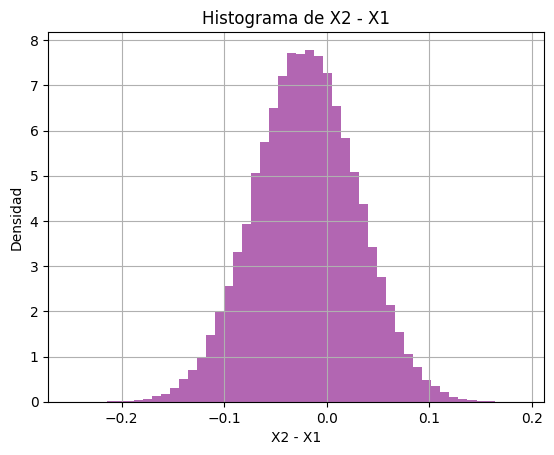

In [9]:
plt.hist(diferencia, bins=50, density=True, alpha=0.6, color='purple')
plt.title('Histograma de X2 - X1')
plt.xlabel('X2 - X1')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()

En el histograma, la parte que queda a la derecha de cero representa los casos donde:

$$
X_2 - X_1 > 0
$$

es decir, los casos donde ocurre interferencia.

## Comprobación teórica

También se puede calcular la probabilidad de manera teórica.

Sea:

$$
Y = X_2 - X_1
$$

Como $X_1$ y $X_2$ son variables normales independientes, entonces $Y$ también sigue una distribución normal.

La media de $Y$ es:

$$
\mu_Y = \mu_2 - \mu_1
$$

$$
\mu_Y = 1.48 - 1.5 = -0.02
$$

La varianza de $Y$ es:

$$
\sigma_Y^2 = \sigma_1^2 + \sigma_2^2
$$

$$
\sigma_Y^2 = 0.0016 + 0.0009 = 0.0025
$$

Por lo tanto:

$$
\sigma_Y = \sqrt{0.0025}=0.05
$$

Entonces:

$$
Y \sim N(-0.02,\;0.0025)
$$

La probabilidad de interferencia es:

$$
P(X_2 > X_1) = P(Y>0)
$$

Estandarizando:

$$
Z = \frac{Y-\mu_Y}{\sigma_Y}
$$

$$
P(Y>0)=P\left(Z>\frac{0-(-0.02)}{0.05}\right)
$$

$$
P(Y>0)=P(Z>0.4)
$$

Por tabla normal:

$$
P(Z>0.4)=1-P(Z\leq 0.4)
$$

$$
P(Z>0.4)=1-0.6554
$$

$$
P(Z>0.4)=0.3446
$$

Por lo tanto, la probabilidad de interferencia es aproximadamente:

$$
P(\text{interferencia}) \approx 0.3446
$$

o sea:

$$
34.46\%
$$

# b) Número de veces que se debe simular el experimento

Ahora se quiere determinar cuántas simulaciones son necesarias para que la probabilidad estimada difiera de su valor verdadero en menos de:

$$
E = 0.01
$$

con un nivel de seguridad del 95%.

Para estimar una proporción, se usa la fórmula:

$$
n = \frac{z_{\alpha/2}^2 p(1-p)}{E^2}
$$

Para un nivel de confianza del 95%:

$$
z_{\alpha/2}=1.96
$$

Del inciso anterior:

$$
p \approx 0.3446
$$

y:

$$
E=0.01
$$

In [10]:
p = 0.3446
E = 0.01
z = 1.96

n_necesario = (z**2 * p * (1 - p)) / (E**2)

n_necesario

8676.28586944

In [11]:
n_necesario_redondeado = np.ceil(n_necesario)

print("Número de simulaciones necesario:", n_necesario_redondeado)

Número de simulaciones necesario: 8677.0


Por lo tanto, se necesitan aproximadamente:

$$
n = 8677
$$

simulaciones.

Se redondea hacia arriba porque no se puede realizar una fracción de simulación.

# Conclusión

La interferencia ocurre cuando el diámetro de la flecha es mayor que el diámetro interno del cojinete:

$$
X_2 > X_1
$$

Usando el método de las 12 uniformes para generar variables normales, se obtuvo una probabilidad simulada cercana a:

$$
P(\text{interferencia}) \approx 0.3446
$$

Esto significa que existe aproximadamente un:

$$
34.46\%
$$

de probabilidad de que haya interferencia en el ensamble.

Además, para que la estimación tenga un error menor que 0.01 con un nivel de confianza del 95%, se necesitan aproximadamente:

$$
8677
$$

simulaciones.